# Headers

In [3]:
from collections import Counter
import os
import matplotlib.pyplot as plt
import pandas as pd
import csv
import json
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Funções Auxiliares

In [5]:
# Define stopwords e pontuação
stopwords_pt = set(stopwords.words('portuguese'))
pontuacao = set(string.punctuation)
aspas_excluir = {'"', "'", "''", "``", "“", "”", "‘", "’", "...", "-", "r", "–", "sobre", "após", "contra"}

def extrair_tokens(texto):
    # Tokeniza o texto
    tokens = word_tokenize(texto.lower(), language='portuguese')

    # Remove pontuações, stopwords e palavras com apenas 1 caractere
    tokens_filtrados = [
        token for token in tokens
        if token not in pontuacao
        and token not in aspas_excluir
        and not token.isnumeric()
    ]
    return tokens_filtrados

In [6]:
def zipf_analysis_and_save(diretorio, nome_corpus, pasta_saida):
    contador_geral = Counter()

    # Iterar pelos arquivos de texto
    for root, _, arquivos in os.walk(diretorio):
        for nome_arquivo in arquivos:
            caminho_arquivo = os.path.join(root, nome_arquivo)
            with open(caminho_arquivo, 'r', encoding='utf-8') as f:
                texto = f.read()
                tokens = extrair_tokens(texto)
                contador_geral.update(tokens)

    palavras_ordenadas = contador_geral.most_common()

    # Criar diretório de saída, se não existir
    os.makedirs(pasta_saida, exist_ok=True)

    # Salvar dados de rank e frequência em CSV
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf.csv")
    with open(caminho_csv, "w", newline='', encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["rank", "frequencia", "palavra"])
        for rank, (palavra, freq) in enumerate(palavras_ordenadas, start=1):
            writer.writerow([rank, freq, palavra])

    # Salvar o dicionário de contagem completo em JSON (opcional)
    caminho_json = os.path.join(pasta_saida, f"{nome_corpus}_contador.json")
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(contador_geral, f, ensure_ascii=False, indent=2)

    print(f"Corpus {nome_corpus} processado e salvo em {pasta_saida}")

In [7]:
def plotar_zipf_de_csv(caminho_csv, nome_corpus):
    ranks = []
    frequencias = []

    with open(caminho_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            ranks.append(int(row["rank"]))
            frequencias.append(int(row["frequencia"]))

    plt.figure(figsize=(8, 6))
    plt.loglog(ranks, frequencias, marker='.')
    plt.title(f'Distribuição de Zipf - {nome_corpus}')
    plt.xlabel('Rank (log)')
    plt.ylabel('Frequência (log)')
    plt.grid(True)
    plt.show()

In [8]:
def plotar_zipf_linear(caminho_csv, nome_corpus):
    ranks = []
    frequencias = []

    with open(caminho_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            ranks.append(int(row["rank"]))
            frequencias.append(int(row["frequencia"]))

    # Gráfico tradicional (escala linear)
    plt.figure(figsize=(10, 6))
    plt.plot(ranks, frequencias, marker='o', linestyle='-', markersize=3, color='blue', label=nome_corpus)
    plt.title(f'Distribuição de Frequência - Lei de Zipf (Escala Linear)\n{nome_corpus}', fontsize=14)
    plt.xlabel('Rank da Palavra', fontsize=12)
    plt.ylabel('Frequência', fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

In [9]:
stopwords_pt = set(stopwords.words('portuguese'))

def zipf_analysis_com_nltk_stopwords(diretorio, nome_corpus, pasta_saida):
    contador_geral = Counter()

    for root, _, arquivos in os.walk(diretorio):
        for nome_arquivo in arquivos:
            caminho_arquivo = os.path.join(root, nome_arquivo)
            with open(caminho_arquivo, 'r', encoding='utf-8') as f:
                texto = f.read()
                tokens = extrair_tokens(texto)
                tokens_filtrados = [t for t in tokens if t not in stopwords_pt]
                contador_geral.update(tokens_filtrados)

    palavras_ordenadas = contador_geral.most_common()

    os.makedirs(pasta_saida, exist_ok=True)

    # Salvar CSV
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf_nltk_stopwords.csv")
    with open(caminho_csv, "w", newline='', encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["rank", "frequencia", "palavra"])
        for rank, (palavra, freq) in enumerate(palavras_ordenadas, start=1):
            writer.writerow([rank, freq, palavra])

    # Salvar JSON
    caminho_json = os.path.join(pasta_saida, f"{nome_corpus}_contador_nltk_stopwords.json")
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(contador_geral, f, ensure_ascii=False, indent=2)

    print(f"Corpus {nome_corpus} (sem stopwords NLTK) processado e salvo em {pasta_saida}")

In [10]:
def mostrar_tabelas_frequencia(caminho_csv):
    # Carrega o CSV de rank/frequência/palavra
    df = pd.read_csv(caminho_csv)

    # Mostra as 10 palavras mais frequentes
    print("🔝 10 palavras mais frequentes:")
    display(df.head(10))

    # Mostra as 10 palavras menos frequentes
    print("\n🔻 10 palavras menos frequentes:")
    display(df.tail(10))

In [11]:
def comparar_top20_lado_a_lado(csv1, csv2):
    nome1 = os.path.basename(csv1).replace("_zipf.csv", "").replace("_zipf_nltk_stopwords.csv", "")
    nome2 = os.path.basename(csv2).replace("_zipf.csv", "").replace("_zipf_nltk_stopwords.csv", "")

    df1 = pd.read_csv(csv1).head(20)[["palavra", "frequencia"]].reset_index(drop=True)
    df2 = pd.read_csv(csv2).head(20)[["palavra", "frequencia"]].reset_index(drop=True)

    tabela = pd.DataFrame({
        f"Palavra {nome1}": df1["palavra"],
        f"Frequência {nome1}": df1["frequencia"],
        f"Palavra {nome2}": df2["palavra"],
        f"Frequência {nome2}": df2["frequencia"],
    })

    display(tabela)

# Fake Human

In [ ]:
fake_br = r""
fake_true_br = r""

corpus_diretorios = {
    "Fake.Br Human": fake_br,
    "FakeTrueBR Human": fake_true_br
}

pasta_saida = r"zipf_results\FakeHuman"

In [93]:
for nome_corpus, caminho in corpus_diretorios.items():
    zipf_analysis_and_save(caminho, nome_corpus, pasta_saida)

Corpus Fake.Br Human processado e salvo em zipf_results\FakeHuman
Corpus FakeTrueBR Human processado e salvo em zipf_results\FakeHuman


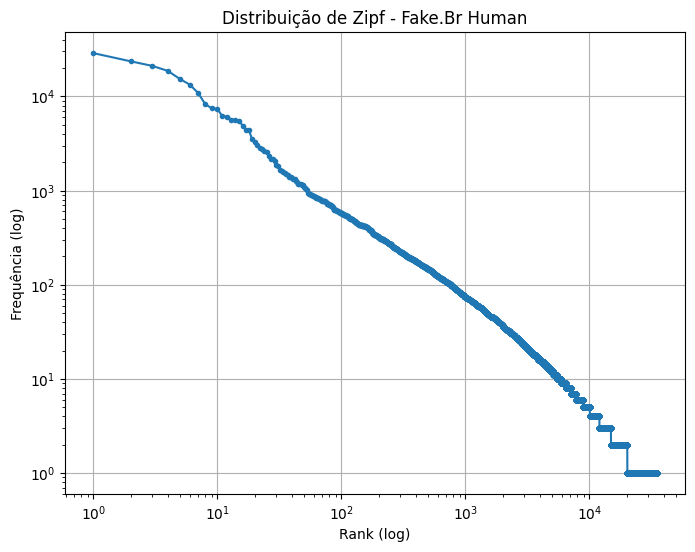

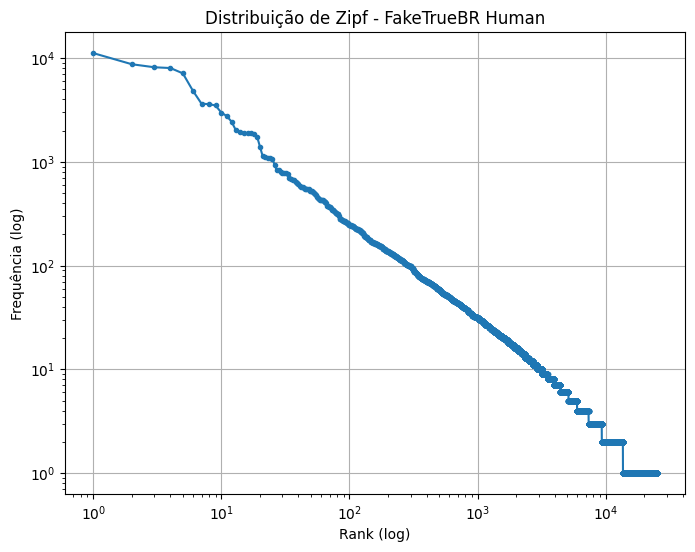

In [94]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf.csv")
    plotar_zipf_de_csv(caminho_csv, nome_corpus)

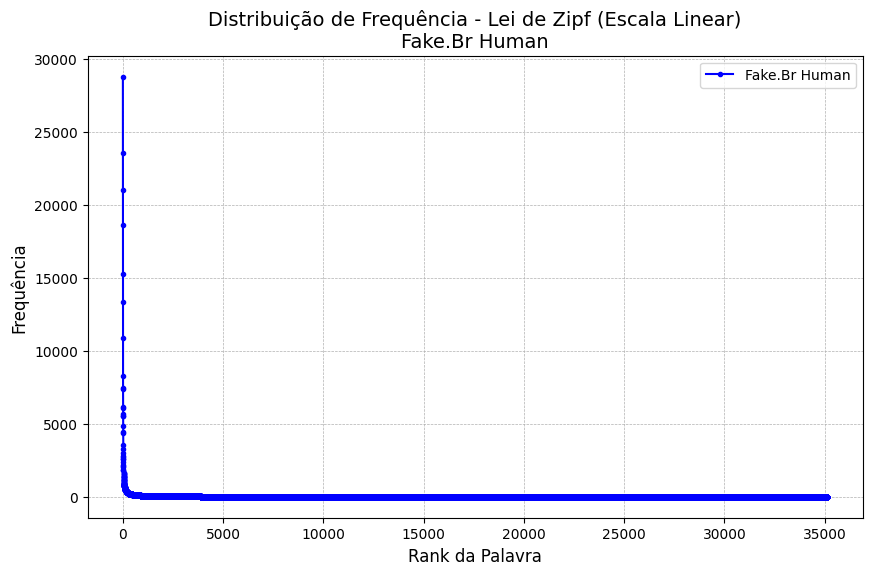

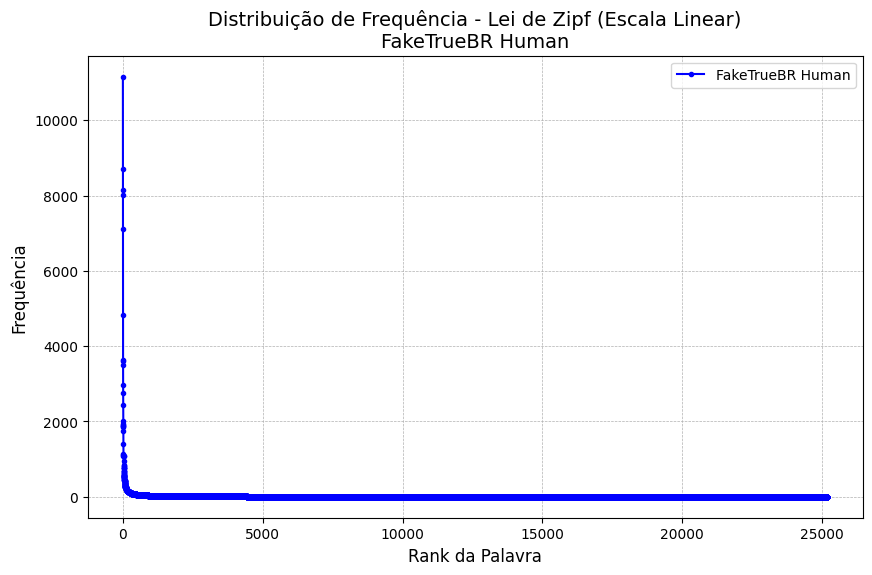

In [95]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf.csv")
    plotar_zipf_linear(caminho_csv, nome_corpus)

## Sem StopWords

In [96]:
for nome_corpus, caminho in corpus_diretorios.items():
    zipf_analysis_com_nltk_stopwords(caminho, nome_corpus, pasta_saida)

Corpus Fake.Br Human (sem stopwords NLTK) processado e salvo em zipf_results\FakeHuman
Corpus FakeTrueBR Human (sem stopwords NLTK) processado e salvo em zipf_results\FakeHuman


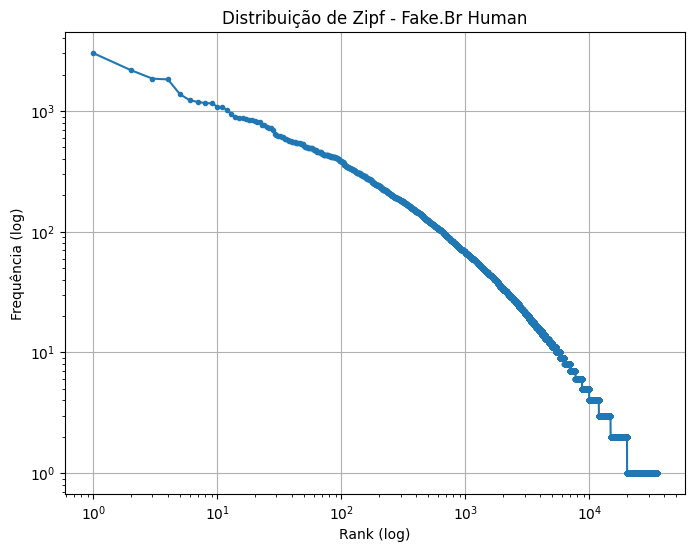

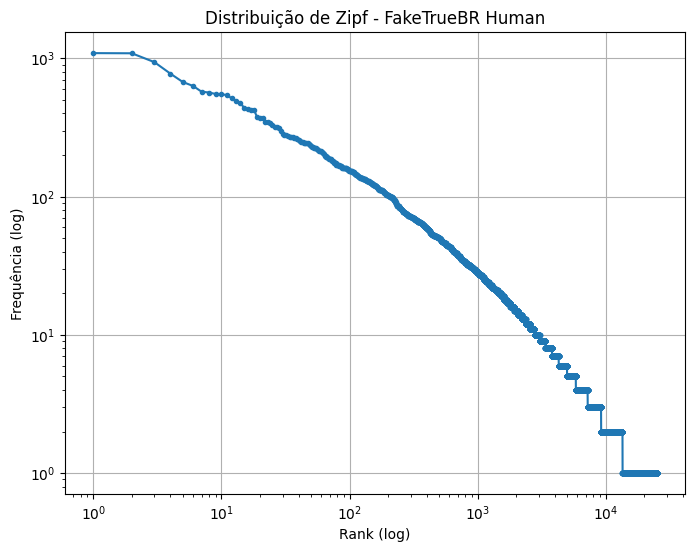

In [97]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf_nltk_stopwords.csv")
    plotar_zipf_de_csv(caminho_csv, nome_corpus)

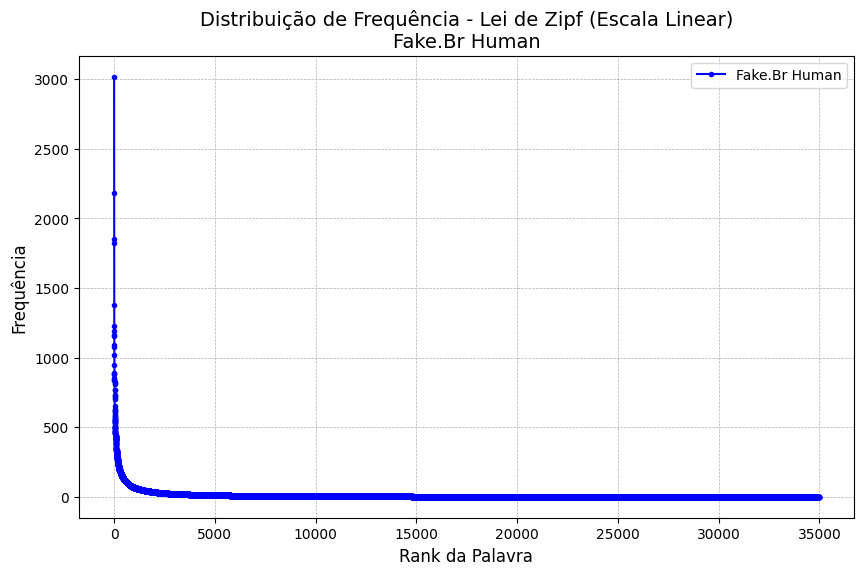

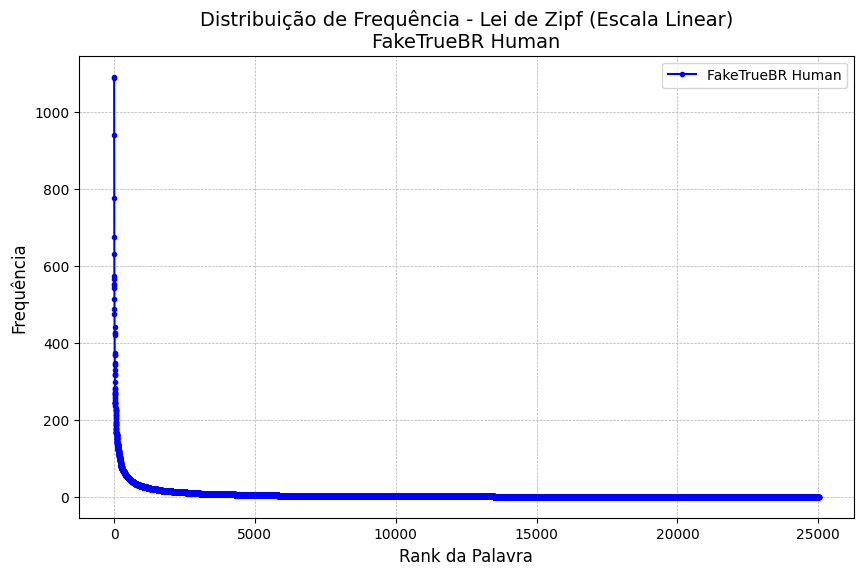

In [98]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf_nltk_stopwords.csv")
    plotar_zipf_linear(caminho_csv, nome_corpus)

In [99]:
resultados_csv = "zipf_results/FakeHuman"

for nome_arquivo in os.listdir(resultados_csv):
    if nome_arquivo.endswith(".csv"):
        caminho_csv = os.path.join(resultados_csv, nome_arquivo)
        print(f"Mostrando tabelas para {nome_arquivo}")
        mostrar_tabelas_frequencia(caminho_csv)

Mostrando tabelas para Fake.Br Human_zipf.csv
🔝 10 palavras mais frequentes:


,rank,frequencia,palavra
0,1,28792,de
1,2,23574,o
2,3,21050,a
3,4,18623,que
4,5,15280,e
5,6,13333,do
6,7,10870,da
7,8,8257,em
8,9,7486,para
9,10,7357,um



🔻 10 palavras menos frequentes:


,rank,frequencia,palavra
35132,35133,1,subdivide
35133,35134,1,autoconhecimento
35134,35135,1,automotivação
35135,35136,1,empatia
35136,35137,1,interpessoais
35137,35138,1,2.0
35138,35139,1,egocentrismo
35139,35140,1,equilibrada
35140,35141,1,denotam
35141,35142,1,importamos


Mostrando tabelas para Fake.Br Human_zipf_nltk_stopwords.csv
🔝 10 palavras mais frequentes:


...

,rank,frequencia,palavra
25178,25179,1,caserna
25179,25180,1,fa
25180,25181,1,enviasse
25181,25182,1,desconfia
25182,25183,1,repentino
25183,25184,1,inexplicável
25184,25185,1,articulados
25185,25186,1,construtoras
25186,25187,1,lucram
25187,25188,1,esperanças


Mostrando tabelas para FakeTrueBR Human_zipf_nltk_stopwords.csv
🔝 10 palavras mais frequentes:


,rank,frequencia,palavra
0,1,1091,bolsonaro
1,2,1088,nao
2,3,939,brasil
3,4,775,vai
4,5,674,lula
5,6,632,todos
6,7,574,anos
7,8,566,whatsapp
8,9,553,presidente
9,10,550,pessoas



🔻 10 palavras menos frequentes:


,rank,frequencia,palavra
25005,25006,1,caserna
25006,25007,1,fa
25007,25008,1,enviasse
25008,25009,1,desconfia
25009,25010,1,repentino
25010,25011,1,inexplicável
25011,25012,1,articulados
25012,25013,1,construtoras
25013,25014,1,lucram
25014,25015,1,esperanças


# Fake LLM

In [ ]:
fake_br = r""
fake_true_br = r""

corpus_diretorios = {
    "Fake.Br LLM": fake_br,
    "FakeTrueBR LLM": fake_true_br
}

pasta_saida = r"zipf_results\FakeLLM"

In [101]:
for nome_corpus, caminho in corpus_diretorios.items():
    zipf_analysis_and_save(caminho, nome_corpus, pasta_saida)

Corpus Fake.Br LLM processado e salvo em zipf_results\FakeLLM
Corpus FakeTrueBR LLM processado e salvo em zipf_results\FakeLLM


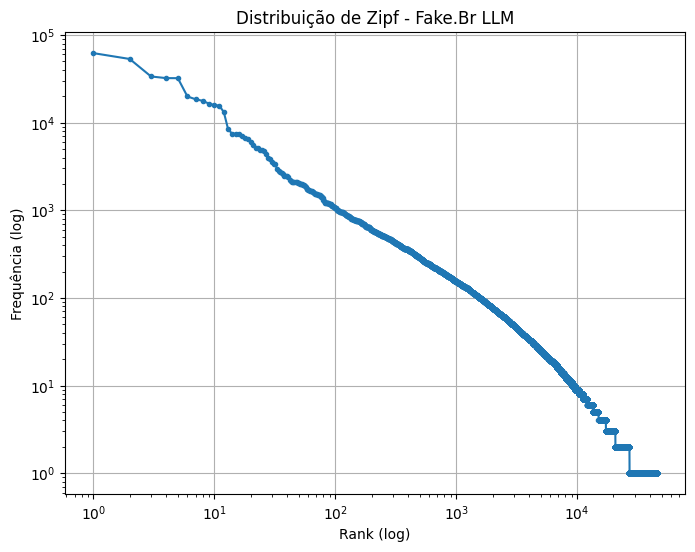

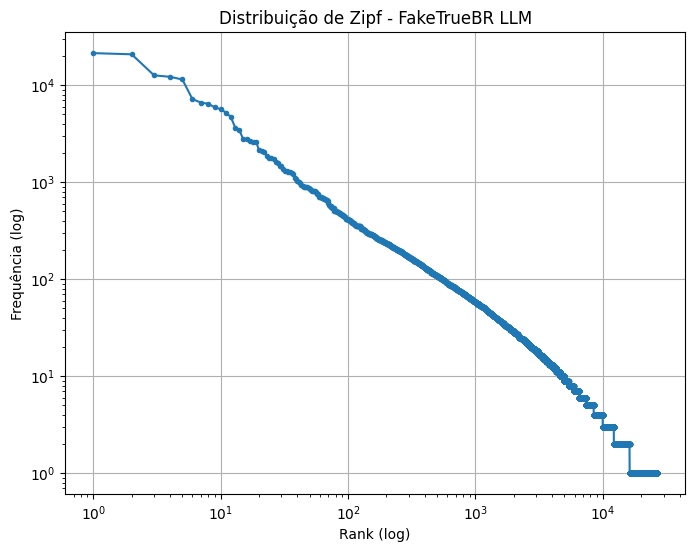

In [102]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf.csv")
    plotar_zipf_de_csv(caminho_csv, nome_corpus)

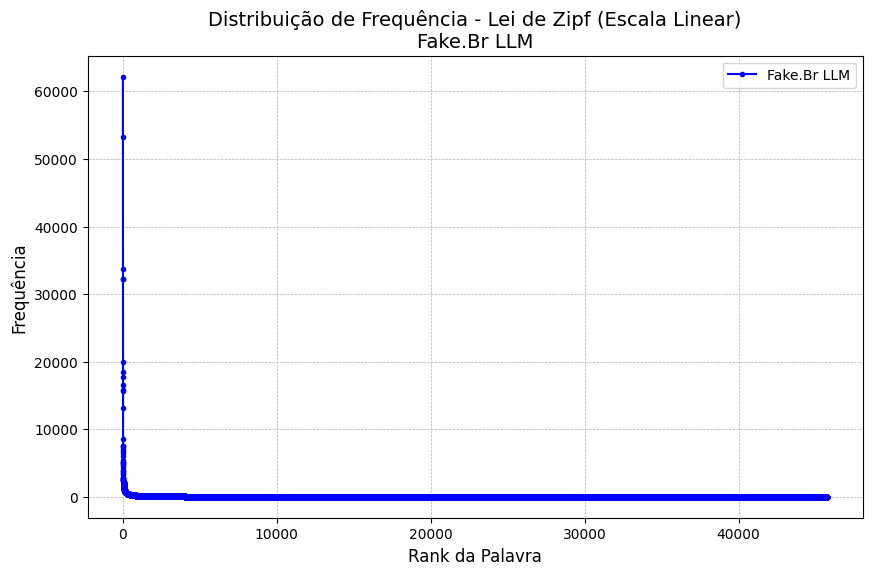

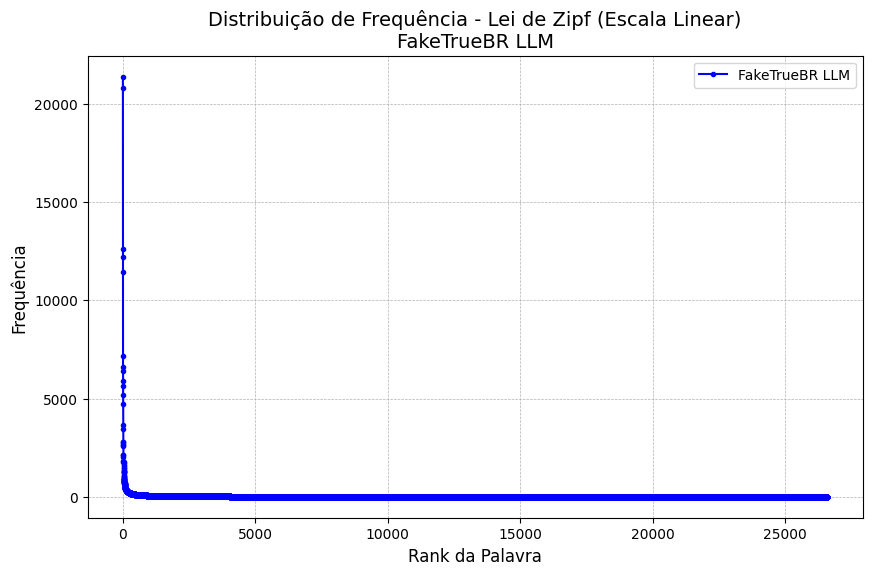

In [103]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf.csv")
    plotar_zipf_linear(caminho_csv, nome_corpus)

## Sem StopWords

In [104]:
for nome_corpus, caminho in corpus_diretorios.items():
    zipf_analysis_com_nltk_stopwords(caminho, nome_corpus, pasta_saida)

Corpus Fake.Br LLM (sem stopwords NLTK) processado e salvo em zipf_results\FakeLLM
Corpus FakeTrueBR LLM (sem stopwords NLTK) processado e salvo em zipf_results\FakeLLM


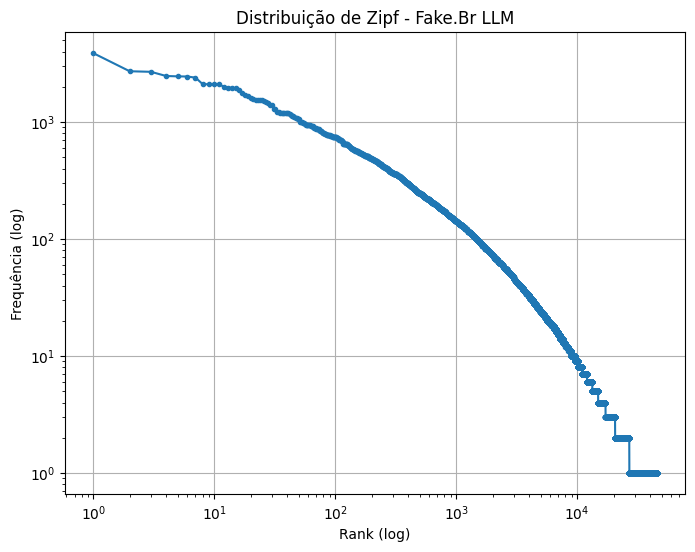

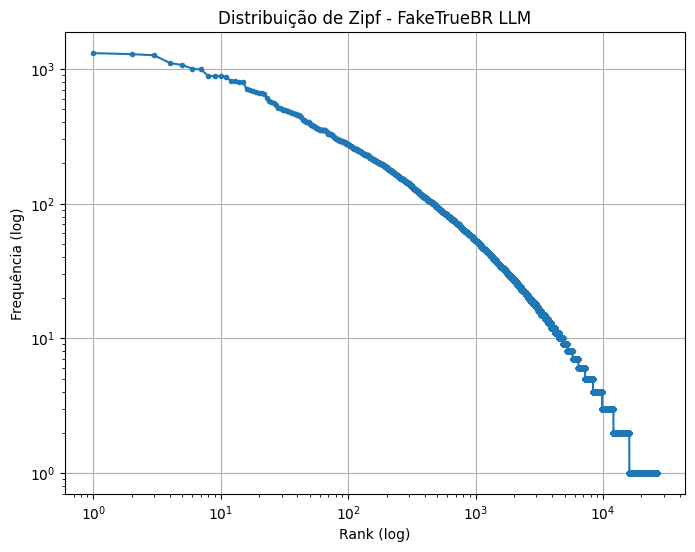

In [105]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf_nltk_stopwords.csv")
    plotar_zipf_de_csv(caminho_csv, nome_corpus)

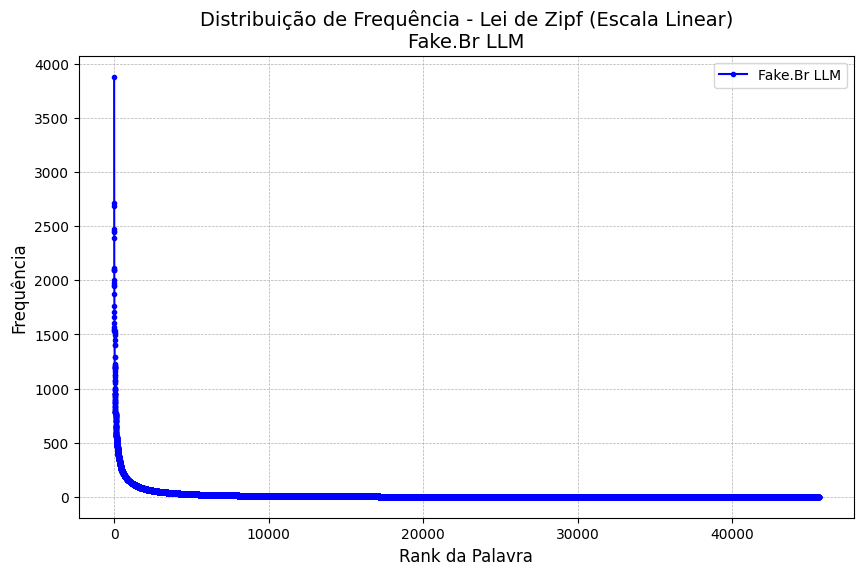

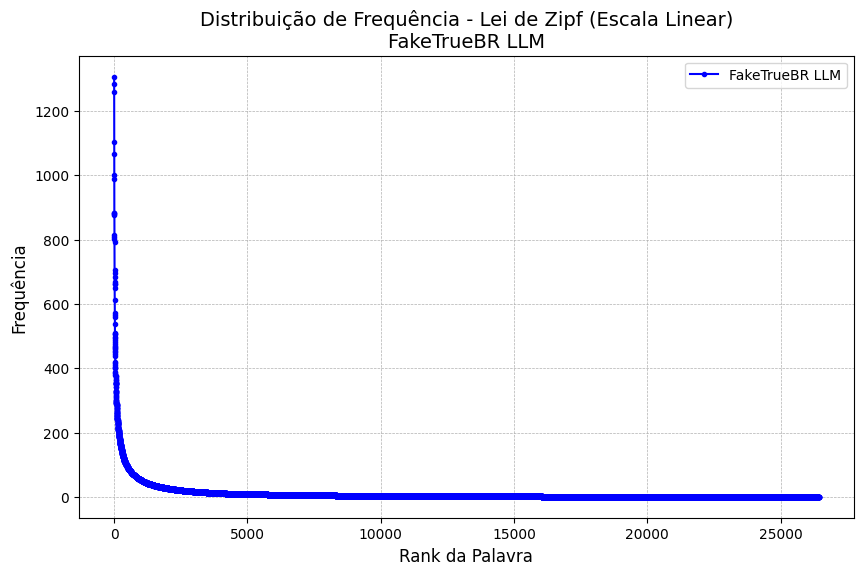

In [106]:
for nome_corpus in corpus_diretorios.keys():
    caminho_csv = os.path.join(pasta_saida, f"{nome_corpus}_zipf_nltk_stopwords.csv")
    plotar_zipf_linear(caminho_csv, nome_corpus)

In [107]:
resultados_csv = "zipf_results/FakeHuman"

for nome_arquivo in os.listdir(resultados_csv):
    if nome_arquivo.endswith(".csv"):
        caminho_csv = os.path.join(resultados_csv, nome_arquivo)
        print(f"Mostrando tabelas para {nome_arquivo}")
        mostrar_tabelas_frequencia(caminho_csv)

Mostrando tabelas para Fake.Br Human_zipf.csv
🔝 10 palavras mais frequentes:


,rank,frequencia,palavra
0,1,28792,de
1,2,23574,o
2,3,21050,a
3,4,18623,que
4,5,15280,e
5,6,13333,do
6,7,10870,da
7,8,8257,em
8,9,7486,para
9,10,7357,um



🔻 10 palavras menos frequentes:


,rank,frequencia,palavra
35132,35133,1,subdivide
35133,35134,1,autoconhecimento
35134,35135,1,automotivação
35135,35136,1,empatia
35136,35137,1,interpessoais
35137,35138,1,2.0
35138,35139,1,egocentrismo
35139,35140,1,equilibrada
35140,35141,1,denotam
35141,35142,1,importamos


Mostrando tabelas para Fake.Br Human_zipf_nltk_stopwords.csv
🔝 10 palavras mais frequentes:


...

,rank,frequencia,palavra
25178,25179,1,caserna
25179,25180,1,fa
25180,25181,1,enviasse
25181,25182,1,desconfia
25182,25183,1,repentino
25183,25184,1,inexplicável
25184,25185,1,articulados
25185,25186,1,construtoras
25186,25187,1,lucram
25187,25188,1,esperanças


Mostrando tabelas para FakeTrueBR Human_zipf_nltk_stopwords.csv
🔝 10 palavras mais frequentes:


,rank,frequencia,palavra
0,1,1091,bolsonaro
1,2,1088,nao
2,3,939,brasil
3,4,775,vai
4,5,674,lula
5,6,632,todos
6,7,574,anos
7,8,566,whatsapp
8,9,553,presidente
9,10,550,pessoas



🔻 10 palavras menos frequentes:


,rank,frequencia,palavra
25005,25006,1,caserna
25006,25007,1,fa
25007,25008,1,enviasse
25008,25009,1,desconfia
25009,25010,1,repentino
25010,25011,1,inexplicável
25011,25012,1,articulados
25012,25013,1,construtoras
25013,25014,1,lucram
25014,25015,1,esperanças


# Análise

In [108]:
csv1 = r"zipf_results\FakeHuman\Fake.Br Human_zipf.csv"
csv2 = r"zipf_results\FakeLLM\Fake.Br LLM_zipf.csv"

comparar_top20_lado_a_lado(csv1, csv2)

,Palavra Fake.Br Human,Frequência Fake.Br Human,Palavra Fake.Br LLM,Frequência Fake.Br LLM
0,de,28792,de,62171
1,o,23574,a,53303
2,a,21050,o,33662
3,que,18623,e,32238
4,e,15280,que,32181
5,do,13333,em,19902
6,da,10870,do,18506
7,em,8257,um,17755
8,para,7486,uma,16532
9,um,7357,da,15865


In [109]:
csv1 = r"zipf_results\FakeHuman\Fake.Br Human_zipf_nltk_stopwords.csv"
csv2 = r"zipf_results\FakeLLM\Fake.Br LLM_zipf_nltk_stopwords.csv"

comparar_top20_lado_a_lado(csv1, csv2)

,Palavra Fake.Br Human,Frequência Fake.Br Human,Palavra Fake.Br LLM,Frequência Fake.Br LLM
0,lula,3018,lula,3880
1,disse,2186,temer,2716
2,dilma,1855,enquanto,2686
3,presidente,1827,ainda,2474
4,brasil,1376,presidente,2456
5,país,1228,apenas,2449
6,governo,1188,federal,2394
7,federal,1164,afirmou,2115
8,temer,1158,corrupção,2099
9,anos,1089,brasil,2098


In [110]:
csv1 = r"zipf_results\FakeHuman\FakeTrueBR Human_zipf.csv"
csv2 = r"zipf_results\FakeLLM\FakeTrueBR LLM_zipf.csv"

comparar_top20_lado_a_lado(csv1, csv2)

,Palavra FakeTrueBR Human,Frequência FakeTrueBR Human,Palavra FakeTrueBR LLM,Frequência FakeTrueBR LLM
0,de,11156,de,21383
1,e,8716,a,20793
2,a,8151,o,12615
3,o,8013,que,12186
4,que,7121,e,11442
5,do,4829,em,7169
6,para,3628,do,6609
7,em,3597,uma,6425
8,da,3491,um,5888
9,no,2977,da,5654


In [111]:
csv1 = r"zipf_results\FakeHuman\FakeTrueBR Human_zipf_nltk_stopwords.csv"
csv2 = r"zipf_results\FakeLLM\FakeTrueBR LLM_zipf_nltk_stopwords.csv"

comparar_top20_lado_a_lado(csv1, csv2)

,Palavra FakeTrueBR Human,Frequência FakeTrueBR Human,Palavra FakeTrueBR LLM,Frequência FakeTrueBR LLM
0,bolsonaro,1091,vídeo,1306
1,nao,1088,sociais,1283
2,brasil,939,redes,1259
3,vai,775,ainda,1102
4,lula,674,bolsonaro,1066
5,todos,632,segundo,1001
6,anos,574,mensagem,988
7,whatsapp,566,pode,883
8,presidente,553,saúde,882
9,pessoas,550,brasil,881
